In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import re
from bs4 import BeautifulSoup
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


c:\Users\test\anaconda3\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
df = pd.read_csv('linprojectdata\WELFake_Dataset.csv')
len(df)

<>:1: SyntaxWarning: invalid escape sequence '\W'
<>:1: SyntaxWarning: invalid escape sequence '\W'
C:\Users\test\AppData\Local\Temp\ipykernel_26580\1595503150.py:1: SyntaxWarning: invalid escape sequence '\W'
  df = pd.read_csv('linprojectdata\WELFake_Dataset.csv')


72134

In [4]:
df_clean = df[(~df['title'].isna()) & (~df['text'].isna())]
df_clean['combined'] = df_clean['title'] + " " + df_clean['text']

C:\Users\test\AppData\Local\Temp\ipykernel_26580\2278758400.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['combined'] = df_clean['title'] + " " + df_clean['text']


In [5]:
df_clean['word_count'] = df_clean['text'].fillna('').apply(lambda x: len(x.split()))

C:\Users\test\AppData\Local\Temp\ipykernel_26580\4268556936.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['word_count'] = df_clean['text'].fillna('').apply(lambda x: len(x.split()))


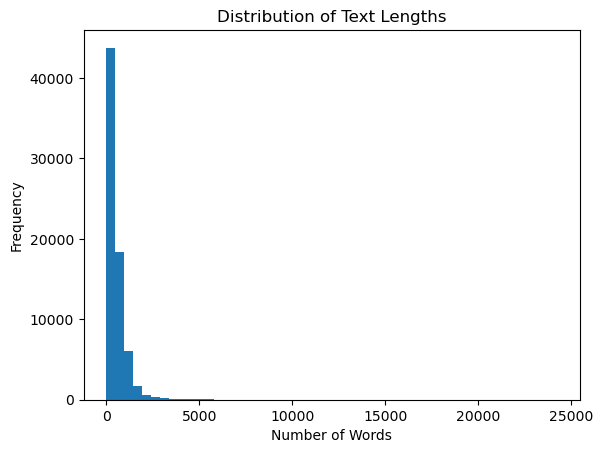

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_clean['word_count'], bins=50)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Text Lengths")
plt.show()

In [7]:
print(df_clean['word_count'].describe())

count    71537.000000
mean       544.562814
std        626.341486
min          0.000000
25%        232.000000
50%        401.000000
75%        670.000000
max      24234.000000
Name: word_count, dtype: float64


In [8]:
Q1 = df_clean['word_count'].quantile(0.25)
Q3 = df_clean['word_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound
outliers = df_clean[
    (df_clean['word_count'] < lower_bound) | 
    (df_clean['word_count'] > upper_bound)
]

print(outliers.shape)
outliers

(4367, 6)


,Unnamed: 0,title,text,label,combined,word_count
23,23,UNHOLY ALLIANCE: Hillary Clinton’s Saudi Spons...,21st Century Wire says Amid the tossing and t...,1,UNHOLY ALLIANCE: Hillary Clinton’s Saudi Spons...,2452
31,31,Credit Suisse Boss Faces Revolt From Bankers O...,When Tidjane Thiam took over at Credit Suisse ...,0,Credit Suisse Boss Faces Revolt From Bankers O...,1501
46,46,Mayday on the Carolina Queen - The New York Times,The seven fishermen aboard the Carolina Queen ...,0,Mayday on the Carolina Queen - The New York Ti...,2893
57,57,OBAMACARE: Wheels Slowly Falling Off The Socia...,Wasn t the point of Obamacare to provide healt...,1,OBAMACARE: Wheels Slowly Falling Off The Socia...,1394
77,77,Collapsing: Why the ‘Russia Hack’ Witch Hunt W...,21st Century Wire says Washington s Russian wi...,1,Collapsing: Why the ‘Russia Hack’ Witch Hunt W...,1563
...,...,...,...,...,...,...
72070,72070,The “American Conservative Movement” Has Ended...,Here's something interesting from The Unz Revi...,1,The “American Conservative Movement” Has Ended...,2387
72087,72087,Ethics Questions Dogged Agriculture Nominee as...,"WASHINGTON — In Sonny Perdue’s telling, Geo...",0,Ethics Questions Dogged Agriculture Nominee as...,1342
72104,72104,Physician Aid in Dying Gains Acceptance in the...,Judith Katherine Dunning had been waiting anxi...,0,Physician Aid in Dying Gains Acceptance in the...,1657
72108,72108,Kris Kobach: Democrats Already Attacking Elect...,Kris Kobach of the Presidential Advisory Com...,0,Kris Kobach: Democrats Already Attacking Elect...,1330


In [9]:
df_clean = df_clean[
    (df_clean['word_count'] > 20) & 
    (df_clean['word_count'] < upper_bound)
]

In [38]:
def clean_text(text):
    remove_words = ["reuters", "getty", "breitbart", "21wire", "twitter", "pic", "com", "www", "http", "https", "2017", "jermone", "jeromeehudson", "siriusxm", "redstone", "dauman", "realdonaldtrump", "_", "jerome", "abrams", "factbox", "pamkeynen"]
    text = text.lower()
    for w in remove_words:
        text = text.replace(w, "")
    return text
def clean_text_soft(text):
    text = BeautifulSoup(text, "lxml").get_text()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df_clean["text_clean"] = df_clean["combined"].apply(clean_text)
df_clean["text_clean"] = df_clean["text_clean"].apply(clean_text_soft)

C:\Users\test\AppData\Local\Temp\ipykernel_26580\548088095.py:8: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "lxml").get_text()


In [39]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df_clean['text_clean'])

In [40]:
label = df_clean['label']
X_train, X_test, y_train, y_test = train_test_split(X, label, test_size=0.2)

In [41]:
model = LogisticRegression()
model.fit(X_train, y_train)

c:\Users\test\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [42]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.956797191054118
Precision: 0.9541685511834765
Recall: 0.9602488241541496
F1-score: 0.9571990320629159


In [43]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_fake_idx = np.argsort(coef)[:20]
top_real_idx = np.argsort(coef)[-20:][::-1]

print("Top 20 features → FAKE (label=0):")
for i in top_fake_idx:
    print(f"  {feature_names[i]:<20} {coef[i]:.4f}")

print("\nTop 20 features → REAL (label=1):")
for i in top_real_idx:
    print(f"  {feature_names[i]:<20} {coef[i]:.4f}")

Top 20 features → FAKE (label=0):
  follow               -3.3583
  edt                  -1.1792
  thursday             -1.1376
  tuesday              -1.0936
  ly                   -1.0660
  friday               -1.0149
  washington           -0.9129
  pam                  -0.8990
  xi                   -0.8963
  spokesman            -0.8810
  wednesday            -0.8748
  saturday             -0.8542
  television           -0.8489
  milo                 -0.8442
  myanmar              -0.8358
  performance          -0.8229
  victim               -0.8183
  macron               -0.8104
  prisoners            -0.8082
  marlow               -0.8036

Top 20 features → REAL (label=1):
  via                  4.6474
  featured             2.9224
  breaking             2.4626
  october              2.0904
  wire                 1.8944
  read                 1.8274
  image                1.7060
  co                   1.6931
  please               1.6025
  november             1.4898
  wow      

In [16]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_positive_idx = coefficients.argsort()[-20:][::-1]
top_positive_words = [(feature_names[i], coefficients[i]) for i in top_positive_idx]

top_positive_idx = coefficients.argsort()[-20:][::-1]
top_positive_words = [(feature_names[i], coefficients[i]) for i in top_positive_idx]

In [17]:
top_negative_idx = coefficients.argsort()[:20]
top_negative_words = [(feature_names[i], coefficients[i]) for i in top_negative_idx]

In [18]:
print("Top positive words:")
for word, coef in top_positive_words:
    print(f"{word}: {coef:.4f}")

print("\nTop negative words:")
for word, coef in top_negative_words:
    print(f"{word}: {coef:.4f}")

Top positive words:
via: 5.1753
featured: 3.1935
breaking: 2.8964
wire: 2.1942
october: 2.1500
read: 2.1333
image: 2.0548
co: 1.9415
snip: 1.7994
please: 1.7913
print: 1.6779
november: 1.6448
nyt: 1.5261
wow: 1.5160
video: 1.4894
watch: 1.4649
nyp: 1.4300
flickr: 1.3792
caller: 1.3689
wfb: 1.3685

Top negative words:
follow: -3.4846
edt: -1.3884
factbox: -1.3472
thursday: -1.3168
jerome: -1.2578
pamkeynen: -1.2189
tuesday: -1.2084
milo: -1.2049
deeply: -1.1523
__: -1.1172
washington: -1.0973
berlin: -1.0843
ly: -1.0804
friday: -1.0558
performance: -1.0395
cartel: -1.0320
macron: -1.0244
xi: -1.0131
weekdays: -0.9960
saturday: -0.9808


In [19]:
import pandas as pd
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]

coef_df = pd.DataFrame({
    "term": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

print(coef_df.head(50))

                 term      coef  abs_coef
175749            via  5.175312  5.175312
63274          follow -3.484618  3.484618
60803        featured  3.193507  3.193507
28047        breaking  2.896437  2.896437
180790           wire  2.194206  2.194206
119092        october  2.150039  2.150039
136667           read  2.133274  2.133274
80504           image  2.054828  2.054828
37304              co  1.941513  1.941513
153847           snip  1.799448  1.799448
128184         please  1.791310  1.791310
131423          print  1.677886  1.677886
117552       november  1.644807  1.644807
118359            nyt  1.526052  1.526052
181745            wow  1.516033  1.516033
175917          video  1.489435  1.489435
178453          watch  1.464872  1.464872
118318            nyp  1.430022  1.430022
53264             edt -1.388406  1.388406
62700          flickr  1.379157  1.379157
30965          caller  1.368930  1.368930
179608            wfb  1.368503  1.368503
59551         factbox -1.347151  1

In [20]:
df_other = pd.read_csv(r"C:\Users\test\Downloads\recovery-news-data.csv")[['title', 'body_text', 'reliability']].rename(columns= {"body_text":"text"})
df_other = df_other[(~df_other['title'].isna()) & (~df_other['text'].isna())]
df_other['combined'] = df_other['title'] + " " + df_other['text']
df_other['label'] = df_other['reliability'].replace({0:1,1:0})
df_other["text_clean"] = df_other["combined"].apply(clean_text)

In [23]:
X2 = vectorizer.transform(df_other['combined'])


In [24]:
y_pred2 = model.predict(X2)

print("Accuracy:", accuracy_score(df_other['label'], y_pred2))
print("Precision:", precision_score(df_other['label'], y_pred2))
print("Recall:", recall_score(df_other['label'], y_pred2))
print("F1-score:", f1_score(df_other['label'], y_pred2))

Accuracy: 0.6717670286278381
Precision: 0.4984391259105099
Recall: 0.7235649546827795
F1-score: 0.5902649414664202


In [25]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

cv = CountVectorizer(binary=True, stop_words="english", min_df=5)
X_bin = cv.fit_transform(df_clean["combined"])
terms = cv.get_feature_names_out()

X_bin_df = pd.DataFrame(X_bin.toarray(), columns=terms)
X_bin_df["label"] = df_clean['label']

doc_presence_0 = X_bin_df[X_bin_df["label"] == 0].drop(columns="label").mean()
doc_presence_1 = X_bin_df[X_bin_df["label"] == 1].drop(columns="label").mean()

presence_df = pd.DataFrame({
    "pct_class0_docs": doc_presence_0,
    "pct_class1_docs": doc_presence_1
})

presence_df["diff"] = presence_df["pct_class1_docs"] - presence_df["pct_class0_docs"]
presence_df["abs_diff"] = presence_df["diff"].abs()

print(presence_df.sort_values("abs_diff", ascending=False).head(50))

            pct_class0_docs  pct_class1_docs      diff  abs_diff
know               0.206136         0.215720  0.009584  0.009584
time               0.359774         0.353273 -0.006501  0.006501
position           0.066164         0.072486  0.006322  0.006322
rules              0.056185         0.050162 -0.006023  0.006023
little             0.118831         0.112890 -0.005941  0.005941
work               0.179481         0.173545 -0.005936  0.005936
support            0.192267         0.198175  0.005908  0.005908
make               0.263911         0.258096 -0.005815  0.005815
lost               0.074857         0.069144 -0.005713  0.005713
really             0.136421         0.142098  0.005678  0.005678
year               0.324392         0.318785 -0.005607  0.005607
years              0.279877         0.274304 -0.005573  0.005573
trying             0.110679         0.115797  0.005118  0.005118
jobs               0.057234         0.052134 -0.005100  0.005100
business           0.1102

WELFake: {'accuracy': 0.9548126097244485, 'precision': 0.9495481927710844, 'recall': 0.9608351112465712, 'f1': 0.9551583093470686}
Recovery: {'accuracy': 0.6717670286278381, 'precision': 0.4984391259105099, 'recall': 0.7235649546827795, 'f1': 0.5902649414664202}


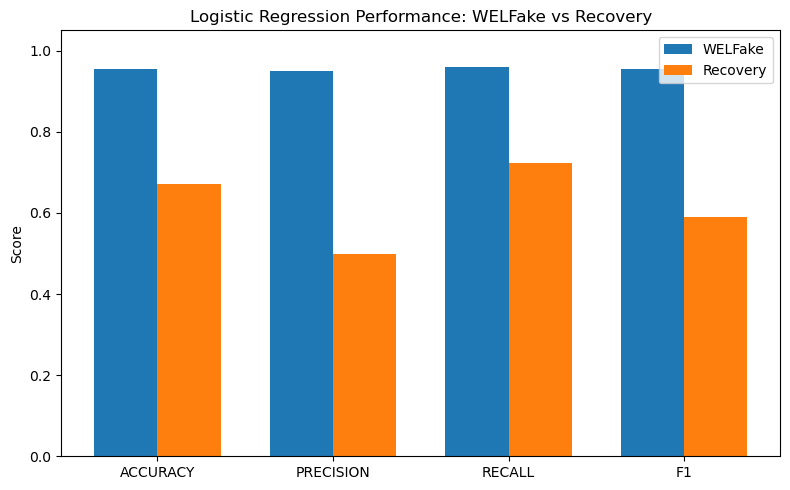

In [27]:
y_pred = model.predict(X_test)          # WELFake
y_pred2 = model.predict(X2)             # Recovery

# Metric values
welfake_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
}

recovery_metrics = {
    "accuracy": accuracy_score(df_other["label"], y_pred2),
    "precision": precision_score(df_other["label"], y_pred2),
    "recall": recall_score(df_other["label"], y_pred2),
    "f1": f1_score(df_other["label"], y_pred2),
}

# Print metrics
print("WELFake:", welfake_metrics)
print("Recovery:", recovery_metrics)

# Bar plot
metric_names = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(metric_names))
width = 0.36

welfake_values = [welfake_metrics[m] for m in metric_names]
recovery_values = [recovery_metrics[m] for m in metric_names]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, welfake_values, width=width, label="WELFake")
plt.bar(x + width/2, recovery_values, width=width, label="Recovery")

plt.xticks(x, [m.upper() for m in metric_names])
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Logistic Regression Performance: WELFake vs Recovery")
plt.legend()
plt.tight_layout()
plt.show()

#### BERT

In [9]:

train_df, test_df = train_test_split(
    df_clean[["text_clean", "label"]],
    test_size=0.2,
    random_state=42,
    stratify=df_clean["label"]
)
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [10]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [11]:
train_dataset = NewsDataset(train_df["text_clean"], train_df["label"], tokenizer)
test_dataset = NewsDataset(test_df["text_clean"], test_df["label"], tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "fake", 1: "real"},
    label2id={"fake": 0, "real": 1},
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

num_epochs = 2

In [14]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {avg_train_loss:.4f}")

    model.eval()
    preds = []
    true_labels = []

    with torch.no_grad():
        for batch in test_loader:
            labels = batch["labels"].cpu().numpy()
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

            preds.extend(batch_preds)
            true_labels.extend(labels)

    acc = accuracy_score(true_labels, preds)
    print(f"Epoch {epoch+1}/{num_epochs} - Test accuracy: {acc:.4f}")

print("\nClassification report:")
print(classification_report(true_labels, preds, target_names=["fake", "real"]))

Epoch 1/2 - Train loss: 0.0514
Epoch 1/2 - Test accuracy: 0.9927
Epoch 2/2 - Train loss: 0.0134
Epoch 2/2 - Test accuracy: 0.9944

Classification report:
              precision    recall  f1-score   support

        fake       0.99      1.00      0.99      6516
        real       1.00      0.99      0.99      6585

    accuracy                           0.99     13101
   macro avg       0.99      0.99      0.99     13101
weighted avg       0.99      0.99      0.99     13101



In [18]:
other_dataset = NewsDataset(df_other["text_clean"], df_other["label"], tokenizer)
other_loader = DataLoader(other_dataset, batch_size=8, shuffle=False)


In [19]:
model.eval()
preds = []
true_labels = []
with torch.no_grad():
        for batch in other_loader:
            labels = batch["labels"].cpu().numpy()
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

            preds.extend(batch_preds)
            true_labels.extend(labels)

        acc = accuracy_score(true_labels, preds)
        print("Accuracy:", accuracy_score(true_labels, preds))
        print("Precision:", precision_score(true_labels, preds))
        print("Recall:", recall_score(true_labels, preds))
        print("F1-score:", f1_score(true_labels, preds))

Accuracy: 0.6219151036525172
Precision: 0.4498069498069498
Recall: 0.7039274924471299
F1-score: 0.5488810365135454


In [20]:
model.eval()
preds = []
true_labels = []
with torch.no_grad():
        for batch in test_loader:
            labels = batch["labels"].cpu().numpy()
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

            preds.extend(batch_preds)
            true_labels.extend(labels)

        acc = accuracy_score(true_labels, preds)
        print("Accuracy:", accuracy_score(true_labels, preds))
        print("Precision:", precision_score(true_labels, preds))
        print("Recall:", recall_score(true_labels, preds))
        print("F1-score:", f1_score(true_labels, preds))

Accuracy: 0.994351576215556
Precision: 0.9954344848577081
Recall: 0.9933181473044799
F1-score: 0.994375190027364


In [ ]:
acc

0.6470878578479763

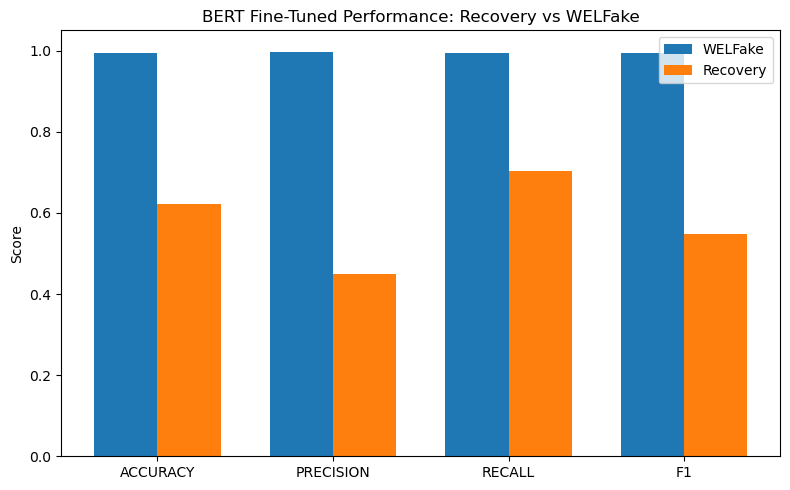

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
recovery_metrics = {
    "accuracy": 0.6219151036525172,
    "precision": 0.4498069498069498,
    "recall": 0.7039274924471299,
    "f1": 0.5488810365135454,
}

welfake_metrics = {
    "accuracy": 0.994351576215556,
    "precision": 0.9954344848577081,
    "recall": 0.9933181473044799,
    "f1": 0.994375190027364,
}

# Plot
metric_names = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(metric_names))
width = 0.36

recovery_values = [recovery_metrics[m] for m in metric_names]
welfake_values = [welfake_metrics[m] for m in metric_names]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, welfake_values, width=width, label="WELFake")
plt.bar(x + width/2, recovery_values, width=width, label="Recovery")


plt.xticks(x, [m.upper() for m in metric_names])
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("BERT Fine-Tuned Performance: Recovery vs WELFake")
plt.legend()
plt.tight_layout()

plt.show()